In [2]:
# Assessment 4 - Part 2: EDA and Visualisation
# Student: Minh Nguyet Tran - s394122

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, mannwhitneyu

In [3]:
# Read file paths and set up output directories
BASE_DIR = Path(r"C:\Users\ASUS\Downloads")
DATA_DIR = BASE_DIR / "outputs_prt564_part1_v2" / "cleaned_data"
OUTPUT_DIR = BASE_DIR / "outputs_prt564_part2_eda" / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RQ1_FILE = DATA_DIR / "rq1_qualification_relevance_part1_dataset_v2.csv"
RQ2_FILE = DATA_DIR / "rq2_migrant_income_part1_dataset_v2.csv"

In [4]:
# Load datasets
rq1 = pd.read_csv(RQ1_FILE)
rq2 = pd.read_csv(RQ2_FILE)
# Basic info about datasets
print("RQ1 shape:", rq1.shape)
print("RQ2 shape:", rq2.shape)
print("\nRQ1 columns:", list(rq1.columns))
print("RQ2 columns:", list(rq2.columns))
# Checking for missing values and duplicates
print("\nRQ1 missing values:\n", rq1.isna().sum())
print("\nRQ2 missing values:\n", rq2.isna().sum())
print("\nRQ1 duplicates:", rq1.duplicated().sum())
print("RQ2 duplicates:", rq2.duplicated().sum())

RQ1 shape: (9946, 18)
RQ2 shape: (284, 7)

RQ1 columns: ['employment_status', 'sex', 'age_group', 'target', 'age_midpoint', 'number_of_non_school_qualifications', 'qualification_recency', 'current_job_skill_level', 'country_of_birth_group', 'citizenship_status', 'occupation', 'occupation_earners_2022_23', 'occupation_median_age_2022_23', 'occupation_sum_income_2022_23', 'occupation_median_income_2022_23', 'occupation_mean_income_2022_23', 'occupation_income_level', 'occupation_income_rank']
RQ2 columns: ['visa_group', 'age_range', 'applicant_status', 'sex', 'arrival_group', 'age_midpoint', 'income_target']

RQ1 missing values:
 employment_status                      0
sex                                    0
age_group                              0
target                                 0
age_midpoint                           0
number_of_non_school_qualifications    0
qualification_recency                  0
current_job_skill_level                0
country_of_birth_group              


RQ1 target counts:
 target
Relevant        8287
Not relevant    1659
Name: count, dtype: int64


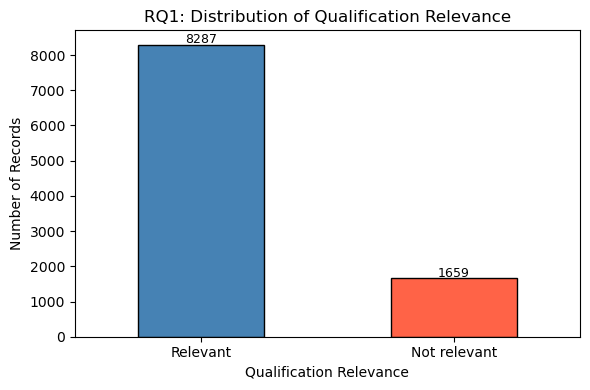


employment_status vs target: chi2=157.67, p=0.0000, df=1


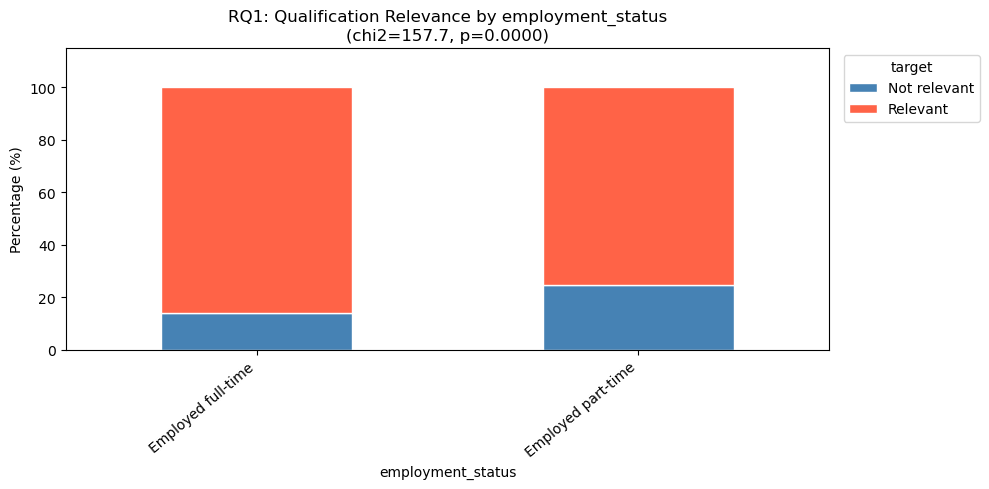


sex vs target: chi2=0.69, p=0.4048, df=1


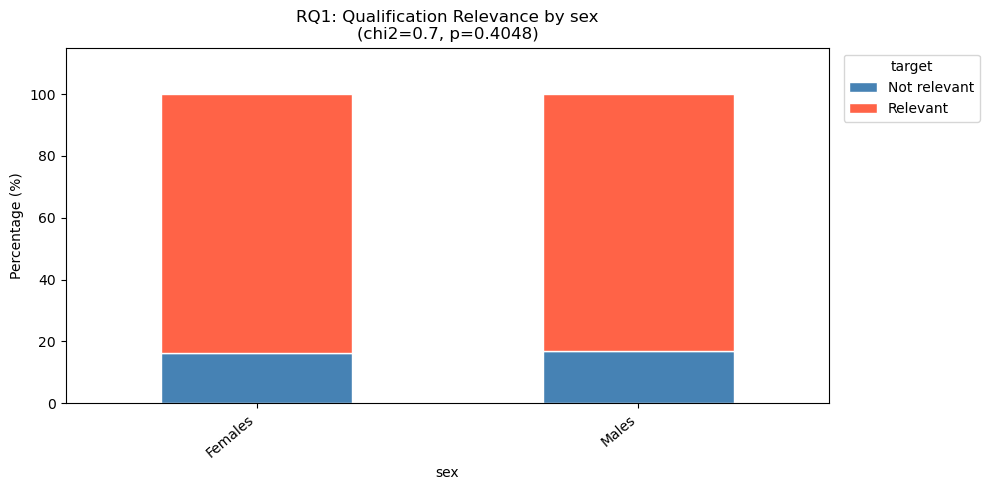


age_group vs target: chi2=81.12, p=0.0000, df=5


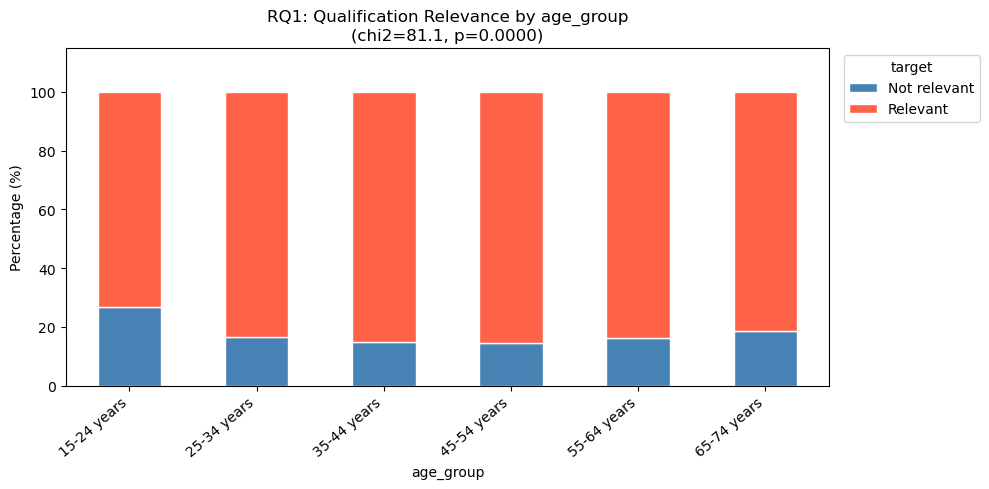


number_of_non_school_qualifications vs target: chi2=52.80, p=0.0000, df=2


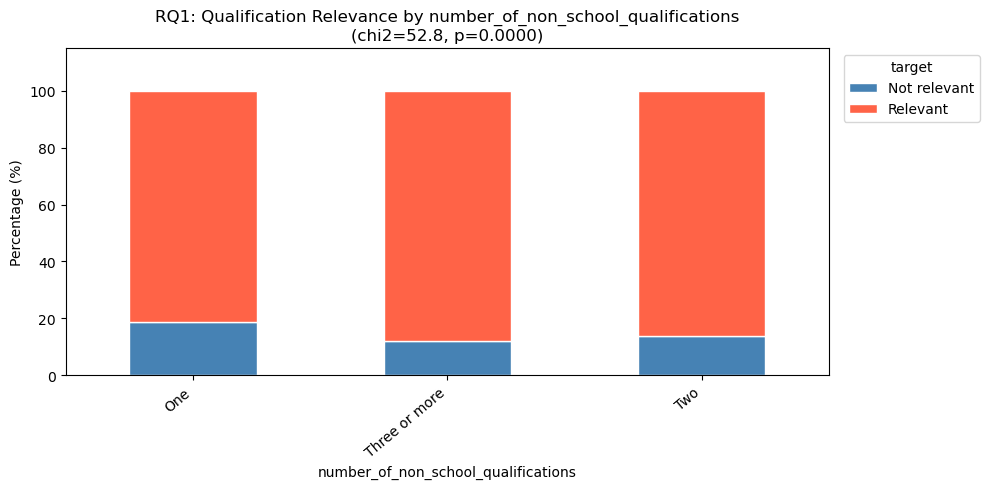


qualification_recency vs target: chi2=0.18, p=0.6752, df=1


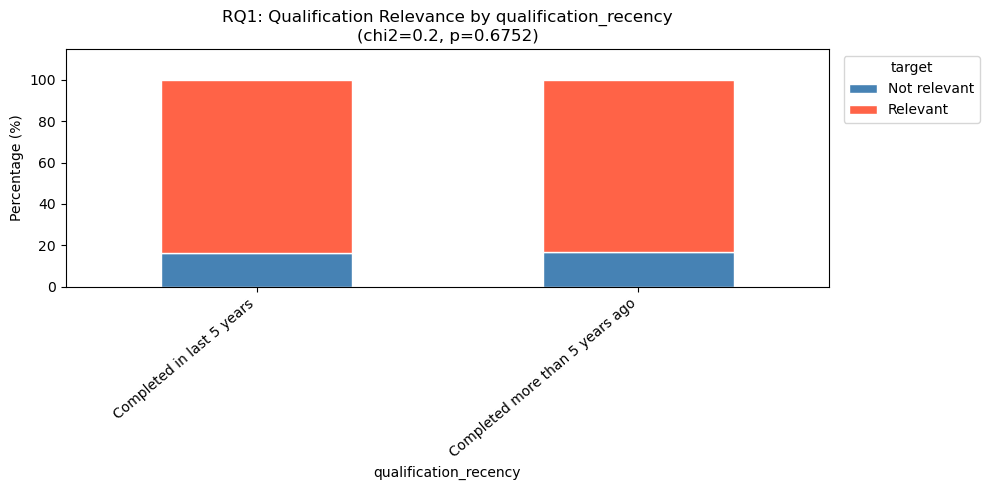


current_job_skill_level vs target: chi2=1419.08, p=0.0000, df=4


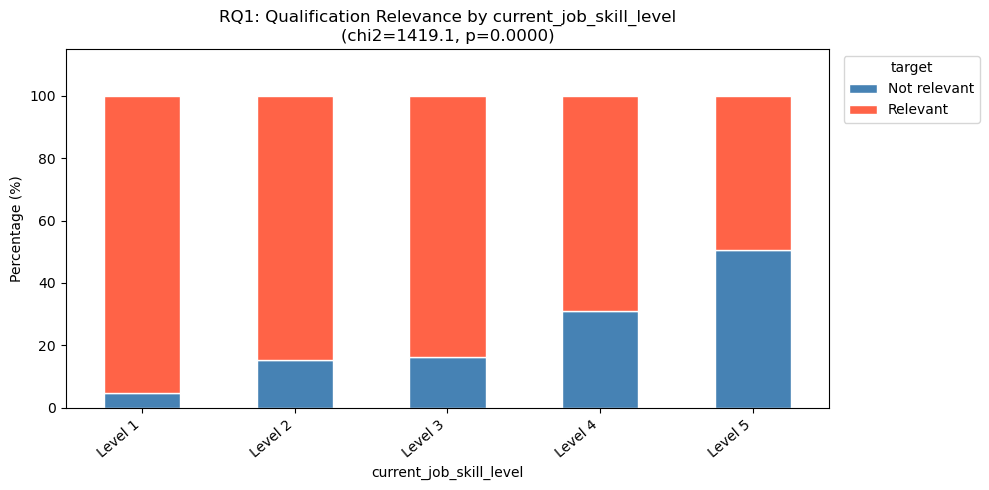


country_of_birth_group vs target: chi2=19.02, p=0.0000, df=1


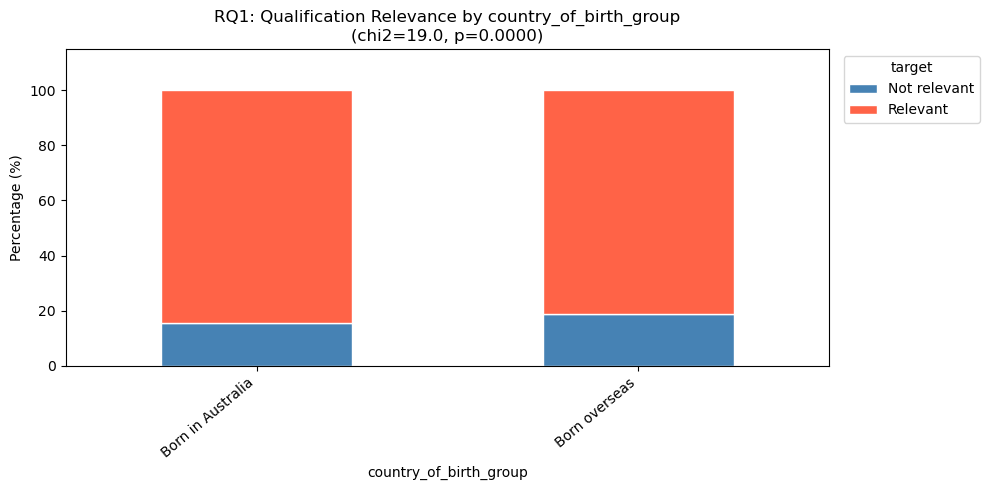


citizenship_status vs target: chi2=96.90, p=0.0000, df=1


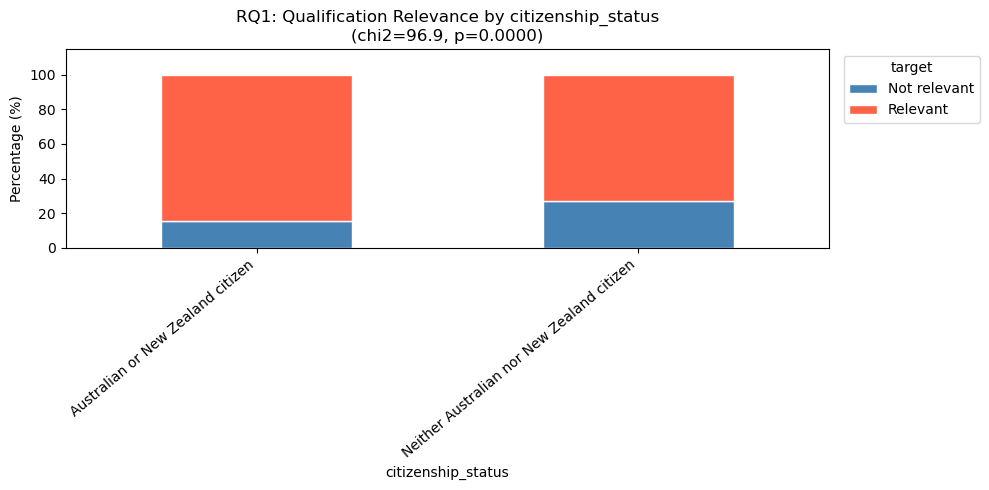


occupation vs target: chi2=1419.65, p=0.0000, df=7


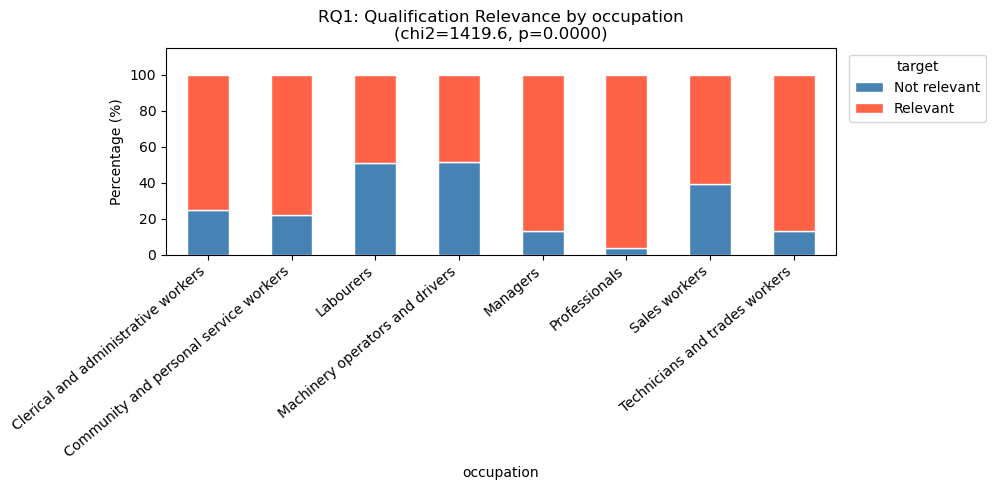


occupation_income_level vs target: chi2=451.42, p=0.0000, df=1


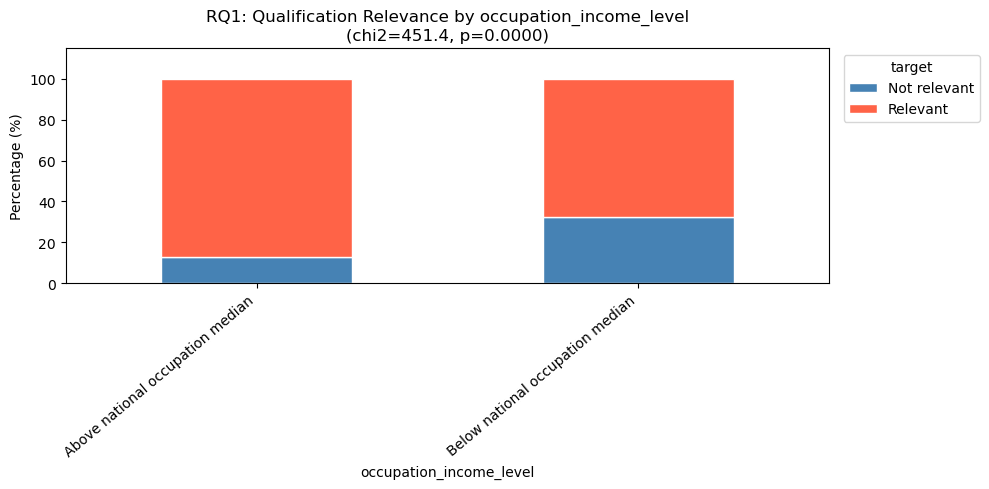

In [5]:
# RQ1 Qualification Relevance
# target distribution
counts = rq1["target"].value_counts()
print("\nRQ1 target counts:\n", counts)
# bar chart of target distribution
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("RQ1: Distribution of Qualification Relevance")
plt.xlabel("Qualification Relevance")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
for i, val in enumerate(counts.values):
    plt.text(i, val + 50, str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq1_target_distribution.png", dpi=150)
plt.show()

# categorical features vs target
rq1_categorical = [
    "employment_status",
    "sex",
    "age_group",
    "number_of_non_school_qualifications",
    "qualification_recency",
    "current_job_skill_level",
    "country_of_birth_group",
    "citizenship_status",
    "occupation",
    "occupation_income_level",
]
# Iterate over all categorical features, create contingency tables against target, run chi-square test, 
# and produce stacked bar plots of percentage distribution
for feature in rq1_categorical:
    ct = pd.crosstab(rq1[feature], rq1["target"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # chi-square test
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"\n{feature} vs target: chi2={chi2:.2f}, p={p:.4f}, df={dof}")

    ax = ct_pct.plot(kind="bar", stacked=True, figsize=(10, 5),
                     color=["steelblue", "tomato"], edgecolor="white")
    plt.title(f"RQ1: Qualification Relevance by {feature}\n(chi2={chi2:.1f}, p={p:.4f})")
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(0, 115)
    plt.legend(title="target", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq1_{feature}_stacked.png", dpi=150)
    plt.show()



age_midpoint Mann-Whitney U: stat=7363266, p=0.0000


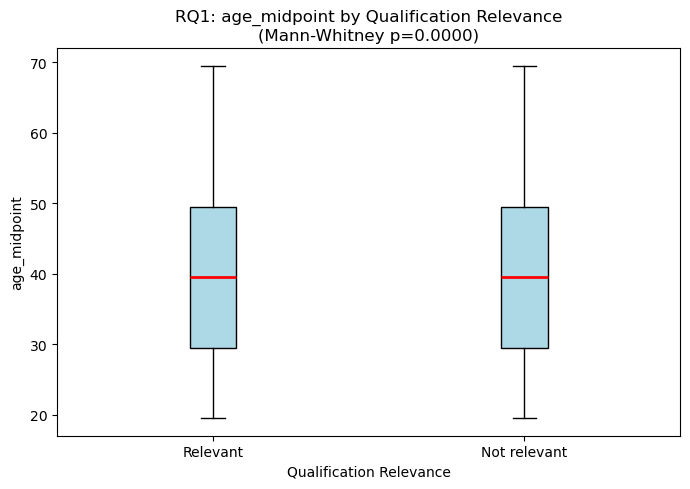


occupation_median_income_2022_23 Mann-Whitney U: stat=10137544, p=0.0000


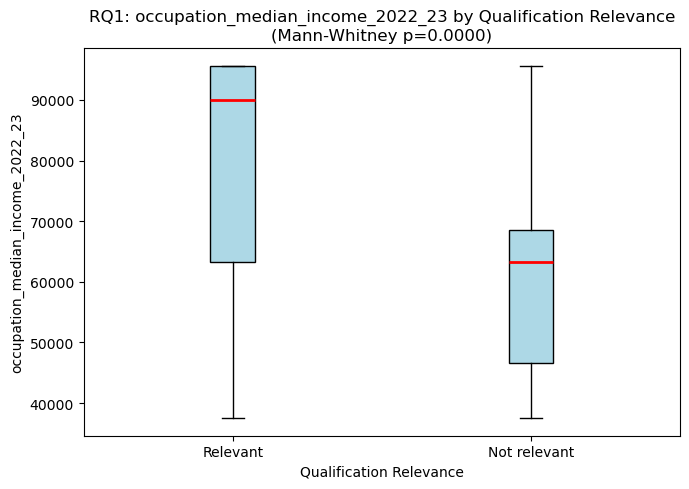


occupation_income_rank Mann-Whitney U: stat=3610590, p=0.0000


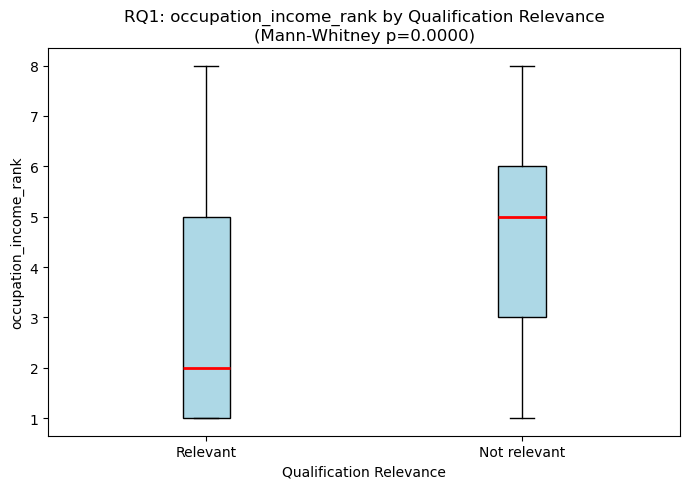

In [7]:
# continuous features vs target
rq1_numerics = [
    "age_midpoint",
    "occupation_median_income_2022_23",
    "occupation_income_rank",
]
# For each numeric variable we will perform comparison of distributions between target groups 
# via boxplot visualisations and Mann-Whitney U test on significance of difference
for col in rq1_numerics:
    groups = [
        rq1.loc[rq1["target"] == lbl, col].dropna().values
        for lbl in rq1["target"].unique()
    ]
    labels = list(rq1["target"].unique())

    stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\n{col} Mann-Whitney U: stat={stat:.0f}, p={p:.4f}")

    plt.figure(figsize=(7, 5))
    plt.boxplot(groups, tick_labels=labels, patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    plt.title(f"RQ1: {col} by Qualification Relevance\n(Mann-Whitney p={p:.4f})")
    plt.xlabel("Qualification Relevance")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq1_{col}_boxplot.png", dpi=150)
    plt.show()


RQ1 Cramer's V scores:
 qualification_recency                  0.0042
sex                                    0.0084
country_of_birth_group                 0.0437
number_of_non_school_qualifications    0.0729
age_group                              0.0903
citizenship_status                     0.0987
employment_status                      0.1259
occupation_income_level                0.2130
current_job_skill_level                0.3777
occupation                             0.3778
dtype: float64


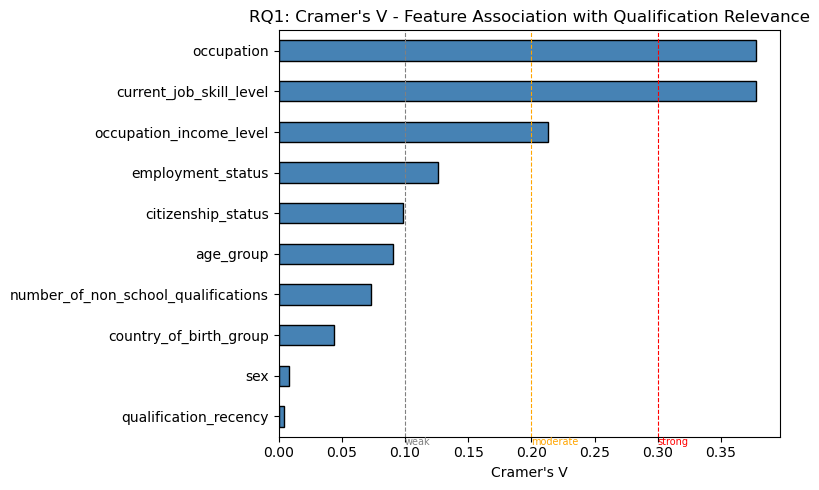

In [8]:
# Cramer's V - associate level of categorical feature and target
# Cramer's V is based on chi-square but scaled between 0 and 1, easier to compare features
cramers_v_scores = {}
for feature in rq1_categorical:
    ct = pd.crosstab(rq1[feature], rq1["target"])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / min(r - 1, k - 1))
    cramers_v_scores[feature] = round(v, 4)

cv_series = pd.Series(cramers_v_scores).sort_values()
print("\nRQ1 Cramer's V scores:\n", cv_series)

plt.figure(figsize=(8, 5))
cv_series.plot(kind="barh", color="steelblue", edgecolor="black")
plt.axvline(0.10, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0.20, color="orange", linestyle="--", linewidth=0.8)
plt.axvline(0.30, color="red", linestyle="--", linewidth=0.8)
plt.text(0.10, -0.7, "weak", fontsize=7, color="grey")
plt.text(0.20, -0.7, "moderate", fontsize=7, color="orange")
plt.text(0.30, -0.7, "strong", fontsize=7, color="red")
plt.title("RQ1: Cramer's V - Feature Association with Qualification Relevance")
plt.xlabel("Cramer's V")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq1_cramers_v.png", dpi=150)
plt.show()


RQ2 target counts:
 income_target
Below median income    142
Above median income    142
Name: count, dtype: int64


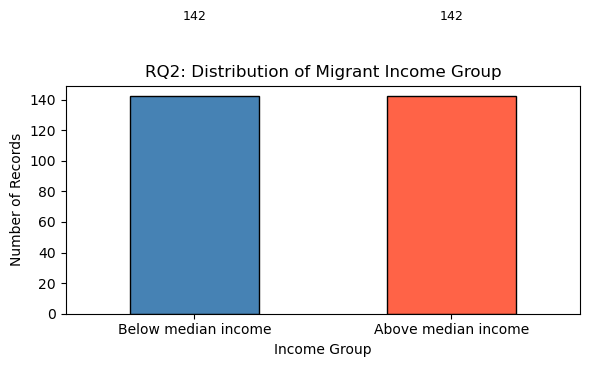

In [10]:
# RQ2 Migrant Income Group
# target distribution
counts2 = rq2["income_target"].value_counts()
print("\nRQ2 target counts:\n", counts2)

plt.figure(figsize=(6, 4))
counts2.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("RQ2: Distribution of Migrant Income Group")
plt.xlabel("Income Group")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
for i, val in enumerate(counts2.values):
    plt.text(i, val + 50, str(val), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_target_distribution.png", dpi=150)
plt.show()



visa_group vs income_target: chi2=60.62, p=0.0000, df=3


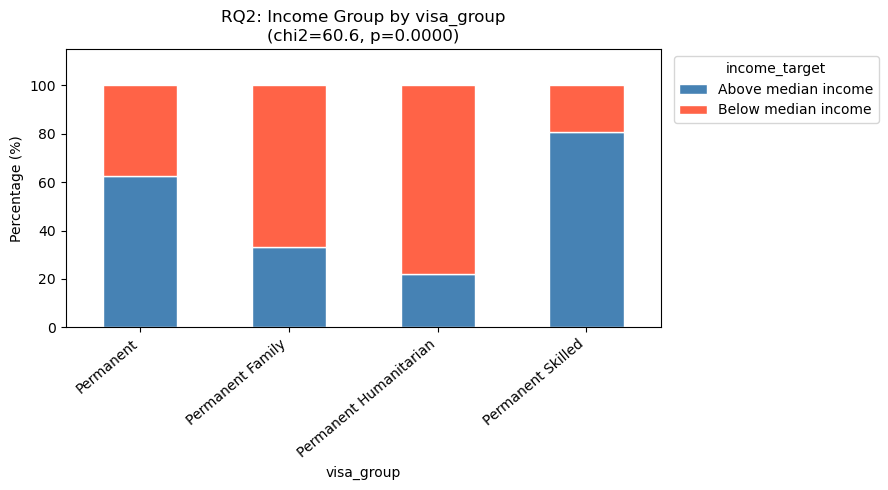


age_range vs income_target: chi2=86.59, p=0.0000, df=5


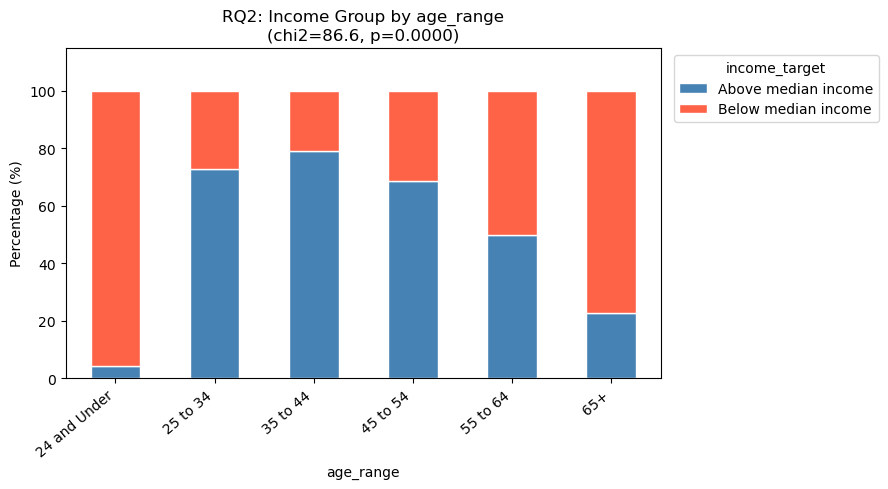


applicant_status vs income_target: chi2=1.14, p=0.2855, df=1


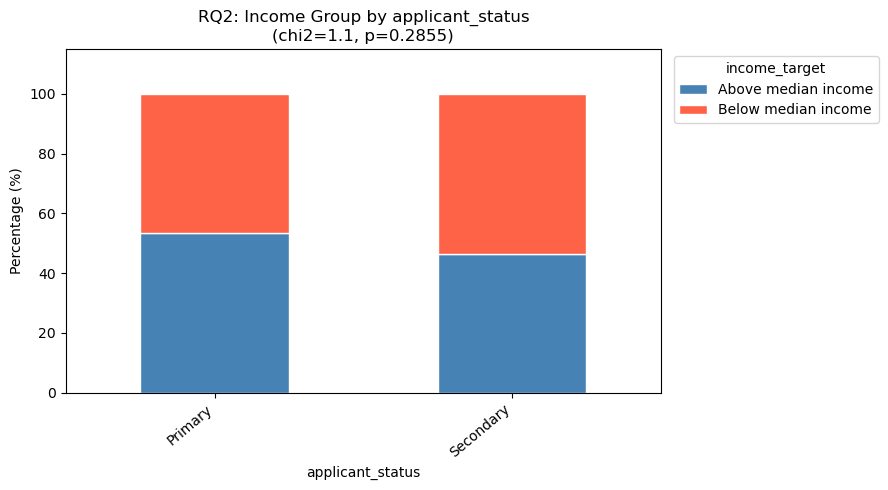


sex vs income_target: chi2=10.27, p=0.0014, df=1


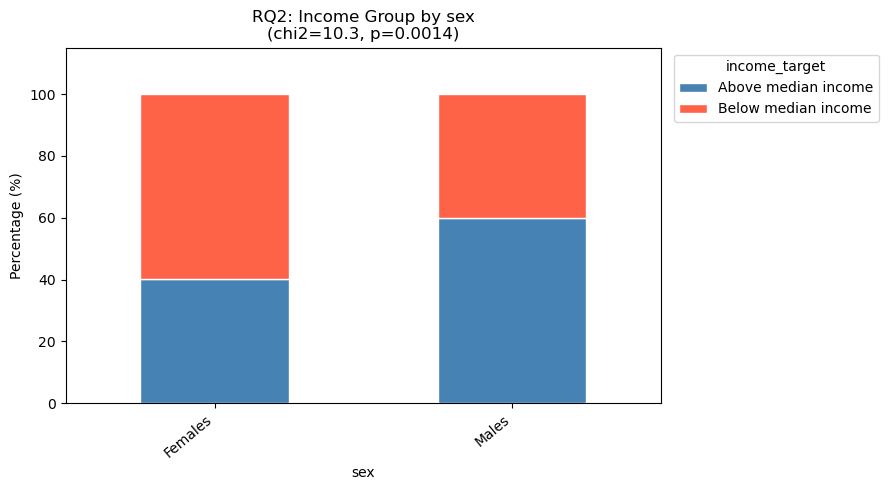


arrival_group vs income_target: chi2=14.40, p=0.0007, df=2


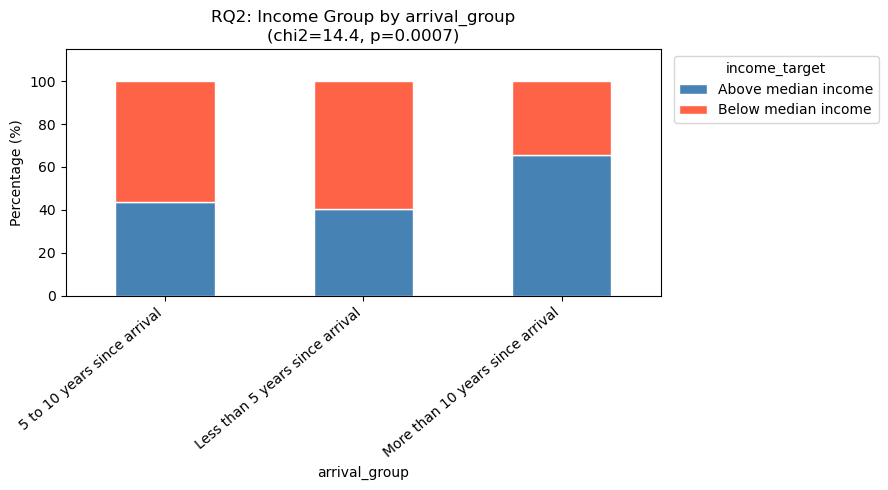


age_midpoint Mann-Whitney U: stat=9770, p=0.6480


C:\Users\ASUS\AppData\Local\Temp\ipykernel_42116\3934173077.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups2, labels=labels2, patch_artist=True,


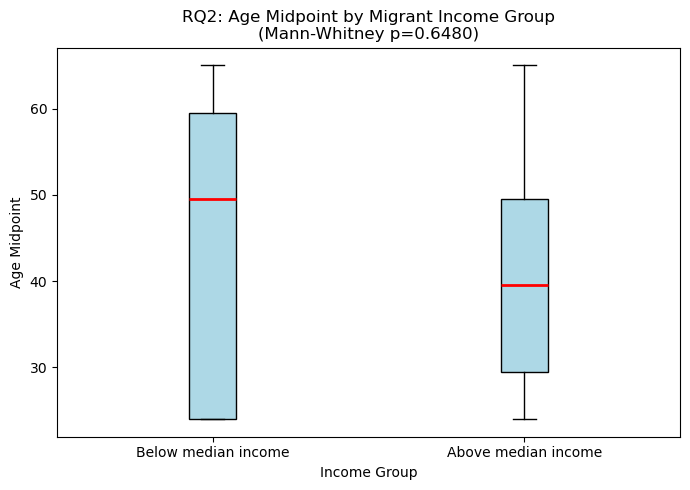

In [11]:
# categorical features vs target
rq2_categorical = [
    "visa_group",
    "age_range",
    "applicant_status",
    "sex",
    "arrival_group",
]

for feature in rq2_categorical:
    ct = pd.crosstab(rq2[feature], rq2["income_target"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"\n{feature} vs income_target: chi2={chi2:.2f}, p={p:.4f}, df={dof}")

    ct_pct.plot(kind="bar", stacked=True, figsize=(9, 5),
                color=["steelblue", "tomato"], edgecolor="white")
    plt.title(f"RQ2: Income Group by {feature}\n(chi2={chi2:.1f}, p={p:.4f})")
    plt.xlabel(feature)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(0, 115)
    plt.legend(title="income_target", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq2_{feature}_stacked.png", dpi=150)
    plt.show()

# age_midpoint vs target
groups2 = [
    rq2.loc[rq2["income_target"] == lbl, "age_midpoint"].dropna().values
    for lbl in rq2["income_target"].unique()
]
labels2 = list(rq2["income_target"].unique())

stat2, p2 = mannwhitneyu(groups2[0], groups2[1], alternative="two-sided")
print(f"\nage_midpoint Mann-Whitney U: stat={stat2:.0f}, p={p2:.4f}")

plt.figure(figsize=(7, 5))
plt.boxplot(groups2, labels=labels2, patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="red", linewidth=2))
plt.title(f"RQ2: Age Midpoint by Migrant Income Group\n(Mann-Whitney p={p2:.4f})")
plt.xlabel("Income Group")
plt.ylabel("Age Midpoint")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"rq2_age_midpoint_boxplot.png", dpi=150)
plt.show()


RQ2 Cramer's V scores:
 applicant_status    0.0634
sex                 0.1901
arrival_group       0.2252
visa_group          0.4620
age_range           0.5522
dtype: float64


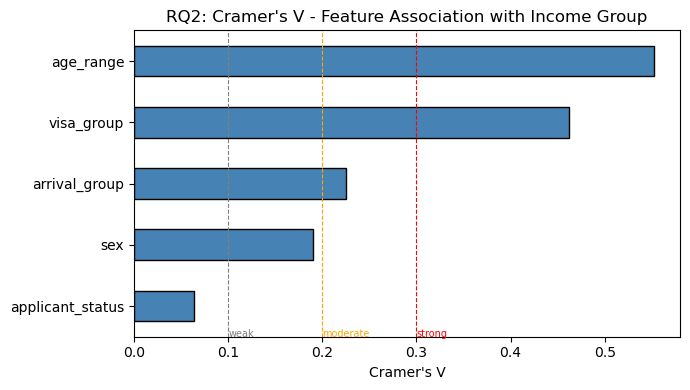

In [12]:
# Cramer's V for RQ2 categorical features
cramers_v_scores2 = {}
for feature in rq2_categorical:
    ct = pd.crosstab(rq2[feature], rq2["income_target"])
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / min(r - 1, k - 1))
    cramers_v_scores2[feature] = round(v, 4)

cv_series2 = pd.Series(cramers_v_scores2).sort_values()
print("\nRQ2 Cramer's V scores:\n", cv_series2)

plt.figure(figsize=(7, 4))
cv_series2.plot(kind="barh", color="steelblue", edgecolor="black")
plt.axvline(0.10, color="grey", linestyle="--", linewidth=0.8)
plt.axvline(0.20, color="orange", linestyle="--", linewidth=0.8)
plt.axvline(0.30, color="red", linestyle="--", linewidth=0.8)
plt.text(0.10, -0.5, "weak", fontsize=7, color="grey")
plt.text(0.20, -0.5, "moderate", fontsize=7, color="orange")
plt.text(0.30, -0.5, "strong", fontsize=7, color="red")
plt.title("RQ2: Cramer's V - Feature Association with Income Group")
plt.xlabel("Cramer's V")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_cramers_v.png", dpi=150)
plt.show()